In [167]:
import qutip as q
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import (AutoMinorLocator)
import numpy as np
%matplotlib inline

For this exercise, we will be using Qutip and its ability to extract the energy levels from a provided Hamiltonian.

To begin, we will examine the Hamiltonian of a standard LC oscillator. This is derived in 101.4.

$\hat{H}=\frac{\hat{Q}^2}{2C} + \frac{\hat{\Phi}^2}{2L}$

This can be rearranged to use creation and annihilation operators, which will allow us to translate this into Qutip code more easily.

$\hat{a}=\frac{1}{\sqrt{\hbar\omega}}(\frac{\hat{\Phi}}{\sqrt{2L}}-i\frac{\hat{Q}}{\sqrt{2C}})\\
\hat{H}=\hbar\omega(\hat{a}^\dagger\hat{a} + \frac{1}{2})$

These operators, $\hat{a}$ and $\hat{a}^\dagger$ represent lowering or increasing the energy state of a quantum system by one. From this, we can deduce that

$E_n=\hbar\omega(n+\frac{1}{2})$

This is what we would expect, as an LC oscillator is a form of harmonic oscillator, with the capacitor energy being viewed as "kinetic energy" and the inductor energy viewed as "potential energy". Thus, we can see clearly that we will have evenly spaced energy levels, spaced by $\hbar\omega$. However, say you are not convinced! Allow us to use Qutip to confirm what we know.

In [137]:
"""
The Hamiltonian of an LC Oscillator
"""
def lc_oscillator(w, N=10):
    H = w * (q.create(N) * q.destroy(N)  + 0.5)

    return q.Qobj(H)

This is the Hamiltonian for an LC oscillator. We include two parameters, $w$ and $N$. $w$ is the frequency of the oscillator (which in the case of this LC oscillator is equal to $\frac{1}{\sqrt{LC}}$) while $N$ is the number of energy states we are choosing to consider. 10 will generally be a good estimate to give us an idea of how a system behaves, but this may be tweaked to your liking. Finally, the functions ```q.create``` and ```q.destroy``` are functions provided by Qutip which allow us the declare annihilation and creation matrices. Below, you can observe what these matrices actually look like.

In [138]:
print(f"The annihilator operator for 4 energy levels, a:\n\n{q.destroy(4)}")
print(f"\n\nThe creation operator for 4 energy levels, a dagger:\n\n{q.create(4)}")

The annihilator operator for 4 energy levels, a:

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         1.         0.         0.        ]
 [0.         0.         1.41421356 0.        ]
 [0.         0.         0.         1.73205081]
 [0.         0.         0.         0.        ]]


The creation operator for 4 energy levels, a dagger:

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         0.         0.         0.        ]
 [1.         0.         0.         0.        ]
 [0.         1.41421356 0.         0.        ]
 [0.         0.         1.73205081 0.        ]]


As one final note, you may notice the omission of $\hbar$ in the above code. For ease of viewing the results, we will assume our energy levels to be in units of $\hbar$.

In [148]:
"""
Plots a set of provided energy levels
"""
def plot_energies(energies):
    fig, ax = plt.subplots(figsize=(3,4.5))
    ax.scatter([1]*len(energies), energies, marker="_", s=20000, linewidth=2, zorder=3)
    ax.set_ylabel(r'Energies ($\hbar$)', fontsize=14)
    ax.grid(linestyle='-', linewidth=1)
    ax.set_xticks([])
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    return fig, ax

We define this function, ```plot_energies```, to give us a visual representation of these energy levels. We can extract the energy levels from the Hamiltonian using Qutip. This will give us a NumPy array of length N containing the energy levels! This can be plotted using our above function. Try playing around with the number of energy levels and the frequency of the system.

20 energy levels for an LC Oscillator of frequency 40:
[ 20.  60. 100. 140. 180. 220. 260. 300. 340. 380. 420. 460. 500. 540.
 580. 620. 660. 700. 740. 780.]


(<Figure size 300x450 with 1 Axes>, <Axes: ylabel='Energies ($\\hbar$)'>)

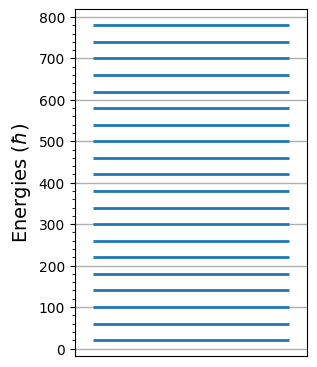

In [149]:
N = 20
w = 40

energies = (np.array(lc_oscillator(w, N).eigenenergies()))

print(f"{N} energy levels for an LC Oscillator of frequency {w}:\n{energies}")

plot_energies(energies)

Another helpful plot will show us the *differences* between energy levels. In engineering superconducting qubits, we seek a system which has a different energy gap between the first two energy levels so we can properly control the state of our system and know what transition we may choose to affect.

In [ ]:
"""
Plots the differences from a set of energies levels
"""
def plot_differences(energies):

    fig, ax = plt.subplots(figsize=(3,4.5))

    # for n in range(len(energies[0,:])):
    #     axes[1].plot(ng_vec, (energies[:,n]-energies[:,0])/(energies[:,1]-energies[:,0]))
    #ax.plot(ng_vec, (energies[:,2]-energies[:,1]))

    diffs = np.delete(energies, 0) - np.delete(energies, len(energies)-1)

    colors = cm.rainbow(np.linspace(0, 1, len(diffs)))
    for diff, col in zip(diffs, colors):
        ax.scatter([1], diff, marker="_", s=20000, linewidth=2, zorder=3, color=col)
    
    ax.set_ylabel(r'Energy Differences ($\hbar$)', fontsize=14)
    ax.grid(linestyle='-', linewidth=1)
    ax.set_xticks([])
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    return fig, ax

(<Figure size 300x450 with 1 Axes>,
 <Axes: ylabel='Energy Differences ($\\hbar$)'>)

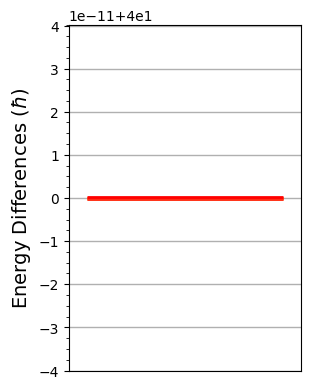

In [185]:
plot_differences(energies)

As we expect, all of the energy levels have the same differences from each other! This demonstrates how a simple LC circuit is unfit to create a qubit. We must modify our circuit to create variations in the energy levels.

In [ ]:
def hamiltonian(Ec, Ej, N, phi, ng, Ej2 = 0):
    """
    Return the charge qubit hamiltonian as a Qobj instance.
    """
    # n = (Ej/(32*Ec))**0.25
   # phi = (2*Ec/Ej)**0.25
    gamma = Ej2 / Ej
    d = (gamma - 1) / (gamma + 1)

    # m = np.sqrt(8*Ec*Ej)*(np.diag(np.sqrt(np.arange(2*N)), -1)*np.diag(np.sqrt(np.arange(2*N)), 1)+0.5)
    # m = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + 0.5 * Ej * (np.diag(-np.ones(2*N), 1) + 
    #                                                            np.diag(-np.ones(2*N), -1))

    m = Ec * (q.destroy(N) * q.create(N) + 0.5)
    
    return q.Qobj(m)

def lc_oscillator(wq, N):
    H = wq * (q.create(N) * q.destroy(N)  + 0.5)

    return q.Qobj(H)

def transmon1(wq, Ec, N):
    H = wq * ( q.create(N) * q.destroy(N)) - (Ec / 2) * (q.create(N) * q.create(N) * q.destroy(N) * q.destroy(N))

    return q.Qobj(H)

def transmon2(Ec, Ej, ng, N):
    H = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + 0.5 * Ej * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

def split_transmon(Ec, Ej, ng, phi, N):
    H = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + Ej * np.abs(np.cos(phi)) * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

def assymetric_transmon(Ec, Ej1, Ej2, ng, phi, N):
    gamma = Ej2 / Ej1
    d = (gamma - 1) / (gamma + 1)
    H = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + (Ej1 + Ej2) * np.sqrt(np.cos(phi)**2 + (d**2)*np.sin(phi)**2) * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

def jaynes_cummings(wr, wq, g, N): 
    a  = q.tensor(q.destroy(N), q.qeye(2))
    sm = q.tensor(q.qeye(N), q.destroy(2))

    H = wr * a.dag() * a + 0.5 * wq * q.tensor(q.qeye(N), q.sigmaz()) + g * (a.dag() * sm + a * sm.dag())
    
    return q.Qobj(H)
     

In [ ]:
    
N = 10  
Ec = 0.3  
Ej = 15
        
    
ng_vec = np.linspace(-4, 4, 200)

energies = (np.array([transmon2(Ec, Ej, 0, N).eigenenergies() for ng in ng_vec]))

# energies = (np.array([assymetric_transmon(Ec, Ej, 2*Ej, 0, ng, N).eigenenergies() for ng in ng_vec]))

plot_energies(ng_vec, energies, ymax=(20, 30))

Created by Tom Steen, 2026.

No AI was used in the creation of this notebook.